# Neural Networks: Forward Propagation From Scratch

This notebook is part of my Machine Learning from Scratch journey.

After completing Course 1 of Andrew Ng's Machine Learning Specialization, I am now starting Course 2: Advanced Learning Algorithms.

In this notebook, I explore the basic structure of neural networks and implement forward propagation from scratch using NumPy.

The main goal is not to train a neural network yet. Instead, the goal is to understand how a neural network takes input features, passes them through layers, and produces an output prediction.

## What This Notebook Covers

In this notebook, I will explore how a basic neural network makes predictions using forward propagation.

The main focus is on:

1. Understanding how a neuron works
2. Building a dense layer from multiple neurons
3. Passing inputs through multiple layers
4. Making a prediction from the final output
5. Comparing a from-scratch NumPy implementation with TensorFlow/Keras

This notebook focuses only on forward propagation. Training, gradient descent, and backpropagation will be covered later.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

## From Logistic Regression to a Neuron

Before neural networks, I learned logistic regression.

Logistic regression makes a prediction by first computing a linear value:

$$
z = w \cdot x + b
$$

Then it applies the sigmoid function:

$$
a = g(z)
$$

where:

$$
g(z) = \frac{1}{1 + e^{-z}}
$$

A single neuron works in a very similar way.

It takes input values, multiplies them by weights, adds a bias, and applies an activation function.

So, a neuron can be thought of as a small computation unit:

$$
a = g(w \cdot x + b)
$$

This is why neural networks feel like an extension of logistic regression. Instead of having just one unit, a neural network has many neurons arranged in layers.


## What is a Neuron?

A neuron is the basic building block of a neural network.

It receives input values, applies weights to those inputs, adds a bias, and then passes the result through an activation function.

For one neuron:

- `x` represents the input features
- `w` represents the weights
- `b` represents the bias
- `z` represents the linear part of the computation
- `a` represents the activation/output of the neuron

The computation is:

$$
z = w \cdot x + b
$$

$$
a = g(z)
$$

The activation function `g` allows the neural network to model non-linear patterns.

## Sigmoid Activation Function

For this notebook, I will use the sigmoid activation function.

The sigmoid function takes any real number and maps it to a value between 0 and 1.

This makes it useful when the output needs to be interpreted as a probability.

For example:

- Output close to `0` means the model is leaning toward class 0
- Output close to `1` means the model is leaning toward class 1

The sigmoid function is:

$$
g(z) = \frac{1}{1 + e^{-z}}
$$

In [2]:
def sigmoid(z):
    """
    Compute the sigmoid of z.

    Args:
        z (float or ndarray): Input value or array of values.

    Returns:
        float or ndarray: Sigmoid output.
    """
    return 1 / (1 + np.exp(-z))

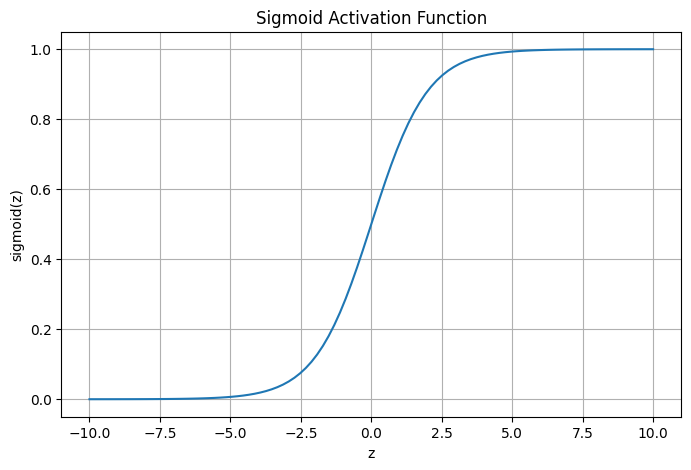

In [3]:
z_values = np.linspace(-10, 10, 100)
sigmoid_values = sigmoid(z_values)

plt.figure(figsize=(8, 5))
plt.plot(z_values, sigmoid_values)
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid Activation Function")
plt.grid(True)
plt.show()

## Implementing a Single Neuron From Scratch

Now I will implement one neuron manually.

A single neuron performs three steps:

1. Multiply each input by its corresponding weight
2. Add the bias
3. Apply an activation function

The formula is:

$$
a = g(w \cdot x + b)
$$

This is the same basic idea as logistic regression.

In [4]:
def neuron_output(x, w, b):
    """
    Compute the output of a single neuron.

    Args:
        x (ndarray): Input features with shape (n,)
        w (ndarray): Weights with shape (n,)
        b (float): Bias term

    Returns:
        float: Output activation of the neuron
    """
    z = np.dot(w, x) + b
    a = sigmoid(z)

    return a

In [5]:
x = np.array([2.0, 3.0])
w = np.array([0.5, -0.2])
b = 0.1

output = neuron_output(x, w, b)

print("Input x:", x)
print("Weights w:", w)
print("Bias b:", b)
print("Neuron output:", output)

Input x: [2. 3.]
Weights w: [ 0.5 -0.2]
Bias b: 0.1
Neuron output: 0.6224593312018546


## Understanding the Shapes

For one neuron, the input vector and weight vector must have the same shape.

If there are two input features:

$$
x = [x_1, x_2]
$$

then the neuron also needs two weights:

$$
w = [w_1, w_2]
$$

The dot product is:

$$
w \cdot x = w_1x_1 + w_2x_2
$$

So if `x.shape` is `(2,)` and `w.shape` is `(2,)`, then `np.dot(w, x)` produces a single number.

That number is then combined with the bias:

$$
z = w \cdot x + b
$$

Finally, the sigmoid activation function is applied:

$$
a = g(z)
$$

## From One Neuron to a Layer

A neural network layer contains multiple neurons.

Each neuron has:

- Its own weight vector
- Its own bias
- Its own output activation

If a layer has three neurons, then the layer will produce three output values.

For example:

    Input features → Layer with 3 neurons → 3 activation values

If the input has two features and the layer has three neurons, each neuron needs two weights.

So the weight matrix will have shape:

    W.shape = (2, 3)

The reason `W` is two-dimensional is that a layer has multiple neurons.

Each column of `W` stores the weights for one neuron.

## Dense Layer From Scratch

A dense layer is a layer where every neuron receives every input from the previous layer.

For a dense layer:

- `a_in` is the input activation vector
- `W` is the weight matrix
- `b` is the bias vector
- `a_out` is the output activation vector

If:

    a_in.shape = (n,)
    W.shape = (n, units)
    b.shape = (units,)

then:

    a_out.shape = (units,)

where `units` is the number of neurons in the layer.

For each neuron, the computation is:

$$
z_j = w_j \cdot a_{in} + b_j
$$

$$
a_j = g(z_j)
$$

In [6]:
def dense_layer(a_in, W, b):
    """
    Compute the output of a dense layer using a loop.

    Args:
        a_in (ndarray): Input activations with shape (n,)
        W (ndarray): Weight matrix with shape (n, units)
        b (ndarray): Bias vector with shape (units,)

    Returns:
        ndarray: Output activations with shape (units,)
    """
    units = W.shape[1]
    a_out = np.zeros(units)

    for j in range(units):
        w_j = W[:, j]

        z_j = np.dot(w_j, a_in) + b[j]
        a_out[j] = sigmoid(z_j)

    return a_out

## Why `W[:, j]` is Used

The weight matrix `W` stores the weights for all neurons in the layer.

If:

    W.shape = (2, 3)

this means:

- There are 2 input values
- There are 3 neurons in the layer

The columns of `W` represent different neurons.

So:

    W[:, 0]

gives the weights for neuron 1.

    W[:, 1]

gives the weights for neuron 2.

    W[:, 2]

gives the weights for neuron 3.

That is why the loop uses:

    w_j = W[:, j]

Each neuron needs its own weight vector.

In [7]:
a_in = np.array([2.0, 3.0])

W = np.array([
    [0.5, -0.3, 0.8],
    [0.2,  0.7, -0.5]
])

b = np.array([0.1, -0.2, 0.3])

a_out = dense_layer(a_in, W, b)

print("Input activations:", a_in)
print("Weight matrix:\n", W)
print("Bias vector:", b)
print("Output activations:", a_out)

Input activations: [2. 3.]
Weight matrix:
 [[ 0.5 -0.3  0.8]
 [ 0.2  0.7 -0.5]]
Bias vector: [ 0.1 -0.2  0.3]
Output activations: [0.84553473 0.78583498 0.59868766]


In [8]:
print("Shape of a_in:", a_in.shape)
print("Shape of W:", W.shape)
print("Shape of b:", b.shape)

print("Shape of a_out:", a_out.shape)

Shape of a_in: (2,)
Shape of W: (2, 3)
Shape of b: (3,)
Shape of a_out: (3,)


## Forward Propagation Through Multiple Layers

Forward propagation means passing input values through the network from left to right.

The output of one layer becomes the input to the next layer.

For example:

    Input layer → Hidden layer → Output layer

If the first layer produces three activations, then the next layer receives those three values as input.

The network does not learn during forward propagation. It only uses the current weights and biases to produce an output.

For a two-layer network:

$$
a^{[1]} = g(xW^{[1]} + b^{[1]})
$$

$$
a^{[2]} = g(a^{[1]}W^{[2]} + b^{[2]})
$$

Here:

- `a[1]` is the activation output of the first layer
- `a[2]` is the final output of the network

## Building a Small Neural Network

Now I will build a small neural network with:

- 2 input features
- 1 hidden layer with 3 neurons
- 1 output layer with 1 neuron

The architecture is:

    Input: 2 features
    Hidden layer: 3 neurons
    Output layer: 1 neuron

This is a very small neural network, but it is enough to understand forward propagation.

In [9]:
def simple_neural_network(x, W1, b1, W2, b2):
    """
    Compute forward propagation for a simple neural network.

    Architecture:
        Input layer -> Hidden layer -> Output layer

    Args:
        x (ndarray): Input features with shape (2,)
        W1 (ndarray): Weights for hidden layer with shape (2, 3)
        b1 (ndarray): Biases for hidden layer with shape (3,)
        W2 (ndarray): Weights for output layer with shape (3, 1)
        b2 (ndarray): Bias for output layer with shape (1,)

    Returns:
        ndarray: Final output activation with shape (1,)
    """
    a1 = dense_layer(x, W1, b1)

    a2 = dense_layer(a1, W2, b2)

    return a2

In [10]:
x = np.array([2.0, 3.0])

W1 = np.array([
    [0.5, -0.3, 0.8],
    [0.2,  0.7, -0.5]
])

b1 = np.array([0.1, -0.2, 0.3])

W2 = np.array([
    [0.4],
    [-0.6],
    [0.9]
])

b2 = np.array([0.2])

prediction_probability = simple_neural_network(x, W1, b1, W2, b2)

print("Prediction probability:", prediction_probability)

Prediction probability: [0.64692087]


## Making a Prediction

The final output of the neural network is a number between 0 and 1 because the output layer uses the sigmoid activation function.

For binary classification, this output can be interpreted as a probability.

A common decision rule is:

    if output >= 0.5:
        predict class 1
    else:
        predict class 0

This threshold-based prediction is similar to what I used in logistic regression.

Mathematically:

$$
\hat{y} =
\begin{cases}
1 & \text{if } a \geq 0.5 \\
0 & \text{if } a < 0.5
\end{cases}
$$

In [11]:
threshold = 0.5

prediction = (prediction_probability >= threshold)

print("Prediction probability:", prediction_probability[0])
print("Predicted class:", int(prediction[0]))

Prediction probability: 0.6469208723471356
Predicted class: 1


## Vectorized Dense Layer

The loop-based implementation is useful for understanding what happens inside each neuron.

However, NumPy allows us to compute the whole layer at once using vectorization.

Instead of looping through each neuron manually, we can compute:

$$
Z = A_{in}W + b
$$

Then apply the activation function:

$$
A_{out} = g(Z)
$$

This is much shorter and more efficient.

In [12]:
def dense_layer_vectorized(a_in, W, b):
    """
    Compute the output of a dense layer using vectorization.

    Args:
        a_in (ndarray): Input activations with shape (n,)
        W (ndarray): Weight matrix with shape (n, units)
        b (ndarray): Bias vector with shape (units,)

    Returns:
        ndarray: Output activations with shape (units,)
    """
    z = np.matmul(a_in, W) + b

    a_out = sigmoid(z)

    return a_out

In [13]:
a_out_loop = dense_layer(a_in, W, b)

a_out_vectorized = dense_layer_vectorized(a_in, W, b)

print("Loop-based output:", a_out_loop)
print("Vectorized output:", a_out_vectorized)

print("Are both outputs close?", np.allclose(a_out_loop, a_out_vectorized))

Loop-based output: [0.84553473 0.78583498 0.59868766]
Vectorized output: [0.84553473 0.78583498 0.59868766]
Are both outputs close? True


## Comparing Loop-Based and Vectorized Implementations

Both implementations should produce the same result.

The loop-based version is easier to understand because it shows how each neuron is computed individually.

The vectorized version is better for real machine learning work because it is faster and uses NumPy operations more efficiently.

The important idea is that both versions are doing the same computation.

Loop-based version:

    for each neuron:
        z = dot product of weights and inputs + bias
        a = activation(z)

Vectorized version:

    z = np.matmul(a_in, W) + b
    a_out = sigmoid(z)

The mathematical idea is:

$$
A_{out} = g(A_{in}W + b)
$$

## TensorFlow Comparison

Andrew Ng's course also introduces neural networks using TensorFlow.

TensorFlow lets us define neural network layers without manually writing all the NumPy calculations.

For example, the same type of network can be written using Keras as:

    model = Sequential([
        Dense(units=3, activation="sigmoid"),
        Dense(units=1, activation="sigmoid")
    ])

This does not mean TensorFlow is doing something completely different.

It is still using the same basic ideas:

- Inputs
- Weights
- Biases
- Activation functions
- Forward propagation

The difference is that TensorFlow handles the details automatically.

In [14]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(2,)),
    Dense(units=3, activation="sigmoid"),
    Dense(units=1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

## TensorFlow Forward Propagation

Now I will use the TensorFlow model to make a prediction.

To make the comparison fair, I will manually set the TensorFlow model's weights equal to the weights used in my NumPy implementation.

This means both models should perform the same forward propagation calculation.

In [15]:
model.layers[0].set_weights([W1, b1])
model.layers[1].set_weights([W2, b2])

In [16]:
X_tf = np.array([[2.0, 3.0]])

print("TensorFlow input:", X_tf)
print("TensorFlow input shape:", X_tf.shape)

TensorFlow input: [[2. 3.]]
TensorFlow input shape: (1, 2)


In [17]:
tf_prediction = model(X_tf).numpy()

print("TensorFlow prediction:", tf_prediction)
print("TensorFlow prediction shape:", tf_prediction.shape)

TensorFlow prediction: [[0.64692086]]
TensorFlow prediction shape: (1, 1)


In [18]:
numpy_prediction = simple_neural_network(x, W1, b1, W2, b2)

print("NumPy prediction:", numpy_prediction)
print("TensorFlow prediction:", tf_prediction[0])
print("Are both predictions close?", np.allclose(numpy_prediction, tf_prediction[0]))

NumPy prediction: [0.64692087]
TensorFlow prediction: [0.64692086]
Are both predictions close? True


## TensorFlow Comparison Summary

The NumPy implementation and TensorFlow model produced the same prediction after using the same weights and biases.

This shows that TensorFlow is performing the same basic forward propagation steps:

$$
z = a_{in}W + b
$$

$$
a_{out} = g(z)
$$

The main difference is that TensorFlow handles the layer structure, weight storage, and matrix operations automatically.

In my NumPy implementation, I manually wrote the dense layer and forward propagation steps. In TensorFlow, I defined the same architecture using `Sequential` and `Dense` layers.

## Final Summary

In this notebook, I learned how neural networks make predictions using forward propagation.

The main ideas are:

1. A neuron computes a weighted sum of inputs, adds a bias, and applies an activation function.
2. A single neuron is similar to logistic regression.
3. A dense layer is made up of multiple neurons.
4. The weight matrix `W` is two-dimensional because each neuron has its own weight vector.
5. Each column of `W` stores the weights for one neuron in my NumPy implementation.
6. Forward propagation passes activations from one layer to the next.
7. The output of one layer becomes the input to the next layer.
8. A neural network can make predictions before it has been trained.
9. Vectorization allows a dense layer to be computed more efficiently.
10. TensorFlow performs the same forward propagation idea, but handles the details automatically.

This notebook focused only on forward propagation. Training, gradient descent, and backpropagation will be covered later.